# FORUM: runbook and artifact validation

This notebook is the reproducible entry point for the manifest-driven FORUM analysis. It can run the upstream stages when `RUN_COMPLETE_PIPELINE` is explicitly set to `True`; by default it only inspects the completed artifacts. The statistical implementation lives in `commentgap_analysis.forum_scores`, and publication figures are generated by `commentgap_analysis.ranking_algorithm_effects`.

The legacy FORUM notebooks (`legacy/03B_forum-table.ipynb`, `legacy/04C_policy-robustness-and-tradeoffs.ipynb`, `legacy/05A_forum-calc-figs.ipynb`, `legacy/05E_forum-dist-figs.ipynb`, `legacy/05F_beta-figs.ipynb`, and `legacy/05G_latex-beta-tables.ipynb`) are methodological references only. This notebook never reads their outputs.
Pinned policies hide every descendant of a sticky comment, including in loose-reply mode. FORUM uses its hidden-comment continuation whenever a policy omits comments. The nDCG agreement diagnostic keeps visible comments first and completes the permutation with a synthetic hidden tail. Rerunning this notebook rebuilds scores and inference made with earlier policy semantics.


In [1]:
from pathlib import Path
import json
import os
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'commentgap_analysis').exists() and (REPO_ROOT.parent / 'commentgap_analysis').exists():
    REPO_ROOT = REPO_ROOT.parent
FORUM_ANALYSIS_ROOT = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis'
INFERENCE_ROOT = FORUM_ANALYSIS_ROOT / 'inference'
REPORTING_ROOT = FORUM_ANALYSIS_ROOT / 'reporting'
print(f'Repository: {REPO_ROOT}')
print(f'FORUM output root: {FORUM_ANALYSIS_ROOT}')

Repository: /home/patrick/Documents/commentgap
FORUM output root: /home/patrick/Documents/commentgap/model_output/selection_2025/forum_ranking_analysis


## Frozen rankers used by FORUM

These are the `draw1` winners frozen by notebook 08 using development cross-validation only. The complete candidate ranking is also shown so the selected model is visible in context.


In [2]:
from commentgap_analysis.forum_scores import freeze_ranker_handoff

selected_path = FORUM_ANALYSIS_ROOT / 'ranker_handoff/selected_rankers.csv'
ranking_path = FORUM_ANALYSIS_ROOT / 'ranker_handoff/development_cv_rankings.csv'
DRAW_POLICIES = ('draw1',)
freeze_ranker_handoff(
    factorial_root=REPO_ROOT / 'model_output/selection_2025/factorial_rankers',
    regression_scores_path=REPO_ROOT / 'model_output/selection_2025/regression/all/test_scores_wide.parquet',
    output_root=FORUM_ANALYSIS_ROOT / 'ranker_handoff',
    draw_policies=DRAW_POLICIES,
)

if selected_path.exists():
    selected_rankers = pd.read_csv(selected_path)
    display(selected_rankers[['family', 'feature_set', 'variant_id', 'audience_column', 'editor_column', 'score_path']])
else:
    print(f'Ranker handoff not available yet: {selected_path}')

if ranking_path.exists():
    candidate_rankers = pd.read_csv(ranking_path)
    display(candidate_rankers.sort_values(['family', 'feature_set', 'development_cv_rank'])[[
        'family', 'feature_set', 'draw_policy', 'variant_id',
        'development_cv_rank', 'mean_macro_ndcg_at_k', 'sd_macro_ndcg_at_k',
        'min_fold_macro_ndcg_at_k'
    ]])
else:
    print(f'Candidate ranking not available yet: {ranking_path}')


,family,feature_set,variant_id,audience_column,editor_column,score_path
0,neural,metadata_bge,nn__metadata_bge__draw1__random4__plateau__sep...,audience_score,curator_score,/home/patrick/Documents/commentgap/model_outpu...
1,neural,metadata,nn__metadata__draw1__random4__plateau__separat...,audience_score,curator_score,/home/patrick/Documents/commentgap/model_outpu...
2,xgboost,metadata_bge,xgb__metadata_bge__draw1,audience_score,curator_score,/home/patrick/Documents/commentgap/model_outpu...
3,xgboost,metadata,xgb__metadata__draw1,audience_score,curator_score,/home/patrick/Documents/commentgap/model_outpu...


,family,feature_set,draw_policy,variant_id,development_cv_rank,mean_macro_ndcg_at_k,sd_macro_ndcg_at_k,min_fold_macro_ndcg_at_k
3,neural,metadata,draw1,nn__metadata__draw1__random4__plateau__separat...,1,0.234001,0.003999,0.227537
5,neural,metadata,draw1,nn__metadata__draw1__random4__plateau__shared_...,2,0.232512,0.004032,0.228347
6,neural,metadata,draw1,nn__metadata__draw1__random4__plateau__separat...,3,0.229178,0.008540,0.216387
8,neural,metadata,draw1,nn__metadata__draw1__random4__plateau__shared_...,4,0.224671,0.008077,0.213680
14,neural,metadata,draw1,nn__metadata__draw1__random4__fixed__separate_...,5,0.213525,0.011489,0.197788
15,neural,metadata,draw1,nn__metadata__draw1__random4__fixed__separate_...,6,0.213311,0.007187,0.202593
16,neural,metadata,draw1,nn__metadata__draw1__random4__fixed__shared_re...,7,0.212010,0.008826,0.198432
18,neural,metadata,draw1,nn__metadata__draw1__random4__fixed__shared_re...,8,0.210981,0.009604,0.199018
22,neural,metadata,draw1,nn__metadata__draw1__hard1_random3__plateau__s...,9,0.201976,0.007761,0.196087
23,neural,metadata,draw1,nn__metadata__draw1__hard1_random3__plateau__s...,10,0.201475,0.006038,0.195657


## Run missing stages, otherwise read existing artifacts

The cells below are the notebook execution path for the complete analysis. Each stage is checked independently and is run only when its expected output is absent or stale. The canonical outcomes are aggregate AQuA, article similarity, maximum toxicity, participant incumbency, prior audience reception, five-nearest-neighbour comment novelty, separate positive and negative sentiment, and raw CTTR and raw SMOG-DE. No alternative toxicity, novelty, semantic-atypicality, or individual-AQuA outcome variants are scored. Because this outcome revision requires rebuilding semantic novelty, set `COMMENTGAP_EMBEDDING_STORE` (or assign `EMBEDDING_STORE`) to the completed frozen BGE store before executing. Scoring uses all CPUs available to the process by default; set `COMMENTGAP_FORUM_WORKERS` to override this.


In [3]:
from commentgap_analysis.forum_scores import (
    DEFAULT_WORKERS, FORUM_ANALYSIS_OUTCOMES, run_forum_analysis_pipeline
)

RUN_MISSING_STAGES = True
EMBEDDING_STORE = REPO_ROOT / (
    "model_output/selection_2025/embeddings/"
    "model=BAAI__bge-m3--d790e737/"
    "build=de5b3016fb2f-010a7cc75a88"
)
SCORING_WORKERS = int(os.getenv('COMMENTGAP_FORUM_WORKERS', str(DEFAULT_WORKERS)))

if RUN_MISSING_STAGES:
    pipeline = run_forum_analysis_pipeline(
        repo_root=REPO_ROOT,
        embedding_store=EMBEDDING_STORE,
        min_comments=11,
        progress_every_stories=10,
        outcomes=FORUM_ANALYSIS_OUTCOMES,
        workers=SCORING_WORKERS,
    )
    display(pd.DataFrame([
        {'stage': stage, 'status': status}
        for stage, status in pipeline['stage_status'].items()
    ]))
else:
    print('RUN_MISSING_STAGES=False: read-only validation mode.')


FORUM freeze: reused
FORUM build: reused
FORUM score: reused
FORUM inference: reused
FORUM report: reused


,stage,status
0,freeze,reused
1,build,reused
2,score,reused
3,infer,reused
4,report,reused


## Check the completed handoff

The expected primary sample is the held-out `paper2_test` partition with at least 11 comments. The large-thread sensitivity is recorded in the analysis table rather than silently changing the primary sample.

In [4]:
expected = {
    'ranker handoff': FORUM_ANALYSIS_ROOT / 'ranker_handoff/ranker_handoff_manifest.json',
    'analysis comments': FORUM_ANALYSIS_ROOT / 'analysis_comments.parquet',
    'policy scores': FORUM_ANALYSIS_ROOT / 'policy_scores/policy_scores.parquet',
    'inference manifest': INFERENCE_ROOT / 'inference_manifest.json',
    'reporting manifest': REPORTING_ROOT / 'reporting_manifest.json',
}
status = pd.DataFrame([{'artifact': label, 'path': str(path), 'exists': path.exists()} for label, path in expected.items()])
display(status)
missing = status.loc[~status['exists'], 'artifact'].tolist()
if missing:
    print('Missing artifacts:', ', '.join(missing))
else:
    print('All expected FORUM stages are present.')

,artifact,path,exists
0,ranker handoff,/home/patrick/Documents/commentgap/model_outpu...,True
1,analysis comments,/home/patrick/Documents/commentgap/model_outpu...,True
2,policy scores,/home/patrick/Documents/commentgap/model_outpu...,True
3,inference manifest,/home/patrick/Documents/commentgap/model_outpu...,True
4,reporting manifest,/home/patrick/Documents/commentgap/model_outpu...,True


All expected FORUM stages are present.


In [5]:
manifests = {}
for label, path in expected.items():
    if path.suffix == '.json' and path.exists():
        manifests[label] = json.loads(path.read_text())

if 'ranker handoff' in manifests:
    handoff = manifests['ranker handoff']
    print('Selected rankers:', len(handoff.get('selected_rankers', [])))
    print('Selection source:', handoff.get('selection_source'))
if 'inference manifest' in manifests:
    inference = manifests['inference manifest']
    print('Bootstrap draws:', inference.get('bootstrap_draws'))
    print('Resampling unit:', inference.get('paired_resampling_unit'))
if 'reporting manifest' in manifests:
    print('Report files:', len(manifests['reporting manifest'].get('outputs', {})))

Selected rankers: 4
Selection source: development_cv_results.csv only
Bootstrap draws: 2000
Resampling unit: discussion
Report files: 11


In [6]:
if expected['analysis comments'].exists() and expected['policy scores'].exists():
    comments = pd.read_parquet(expected['analysis comments'])
    scores = pd.read_parquet(expected['policy scores'])
    summary = pd.DataFrame({
        'quantity': ['comments', 'discussions', 'policy definitions', 'outcomes', 'depths', 'score rows'],
        'value': [
            len(comments), comments['story_id'].nunique(),
            scores[['policy_id', 'ordering', 'reply_mode', 'pinned']].drop_duplicates().shape[0],
            scores['outcome'].nunique(), scores['depth'].nunique(), len(scores),
        ],
    })
    display(summary)
    display(scores.groupby(['ordering', 'reply_mode', 'pinned'], dropna=False).size().to_frame('rows'))

,quantity,value
0,comments,1203611
1,discussions,2556
2,policy definitions,90
3,outcomes,46
4,depths,2
5,score rows,21163680


rows
ordering                 reply_mode pinned        
chronological            hidden     False   235152
                                    True    235152
                         loose      False   235152
                                    True    235152
                         trees      False   235152
...                                            ...
xgb_metadata_text_editor hidden     True    235152
                         loose      False   235152
                                    True    235152
                         trees      False   235152
                                    True    235152

[90 rows x 1 columns]

## Conceptual FORUM calculation

This reproduces the legacy beta-distributed example and example-policy construction, but renders the schematic with the current paper theme and notation. The NumPy seed is explicit here so the example is stable across notebook runs. The PDF is written directly to the Paper 2 manuscript figure directory.

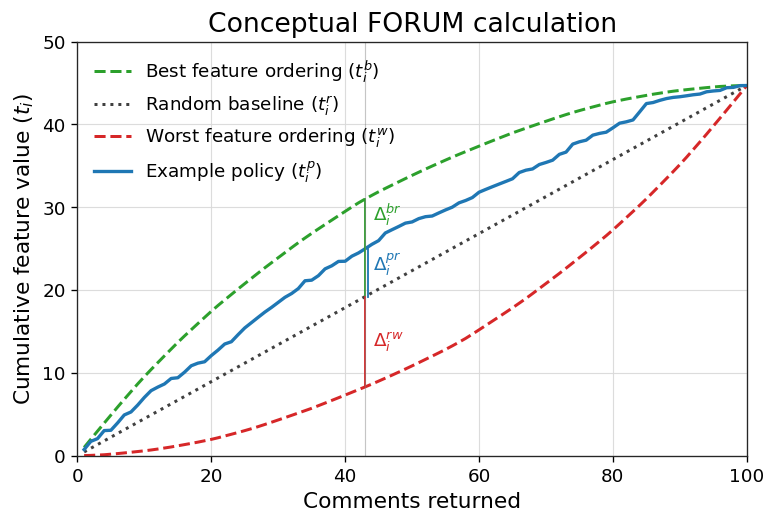

In [7]:
import random
import numpy as np
from commentgap_analysis.forum_plotting import plot_forum_calculation

# Same conceptual example as legacy/05A_forum-calc-figs.ipynb.
np.random.seed(100)
random.seed(100)
size = mm = 100
rlist = list(np.random.beta(1, 1, size))
sorted_rlist = sorted(rlist, reverse=True)
# Preserve the legacy example policy: partially ordered, then locally shuffled.
a1 = sorted_rlist.copy()
a1[::2] = random.sample(a1[::2], len(a1) // 2)
actual = sum([random.sample(a1[n:n + 10], 10) for n in range(0, len(a1), 10)], [])
policy_order = (a1[:5] +
         sum([random.sample(a1[n + 5:n + 15], 10)
              for n in range(0, len(a1) - 10, 10)], []) +
         a1[-5:])
policy_cumulative = np.cumsum(policy_order)

MANUSCRIPT_FIGURE_ROOT = REPO_ROOT / 'submissions/CommentGap2/figures'
plot_forum_calculation(
    rlist,
    policy_cumulative,
    rank_i=43,
    output_paths=(
        MANUSCRIPT_FIGURE_ROOT / 'feature_score.pdf',
        MANUSCRIPT_FIGURE_ROOT / 'feature_score.svg',
    ),
    show=True,
)